In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
titanic = sns.load_dataset("titanic")
titanic.head()
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [3]:

features = ["pclass","sex","fare","embarked","age"]
target = ["survived"]

In [4]:
#Handle missing value
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy = "median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy = "most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])


In [5]:
#encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [6]:
X = titanic[features]
y = titanic[target]

In [7]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size = 0.3,random_state = 42
)

In [8]:
#decision tree classifier model
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [9]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
print("accuracy",accuracy_score(y_test,y_pred))

accuracy 0.7611940298507462


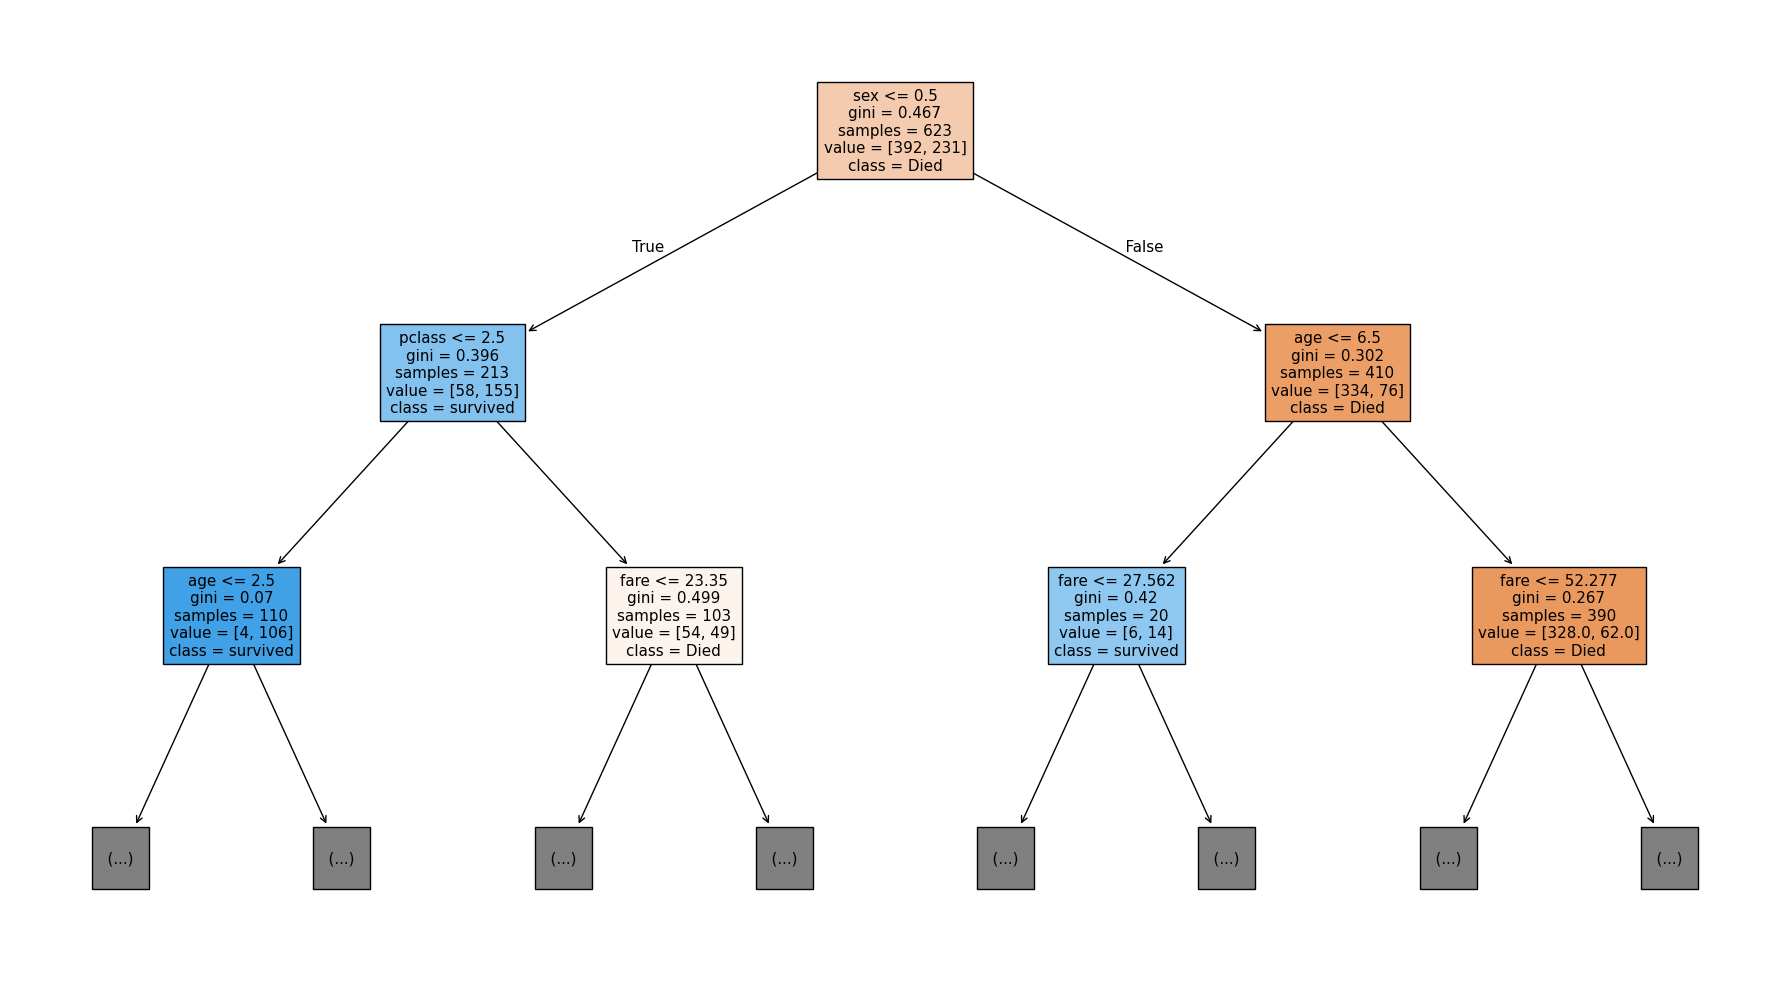

In [10]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died","survived"],
    filled = True,
    max_depth = 2
)
plt.tight_layout()
plt.show()

# Decision Tree with pre-pruning

for depth = 2,accuracy = 0.7723880597014925
for depth = 3,accuracy = 0.8059701492537313
for depth = 4,accuracy = 0.8246268656716418


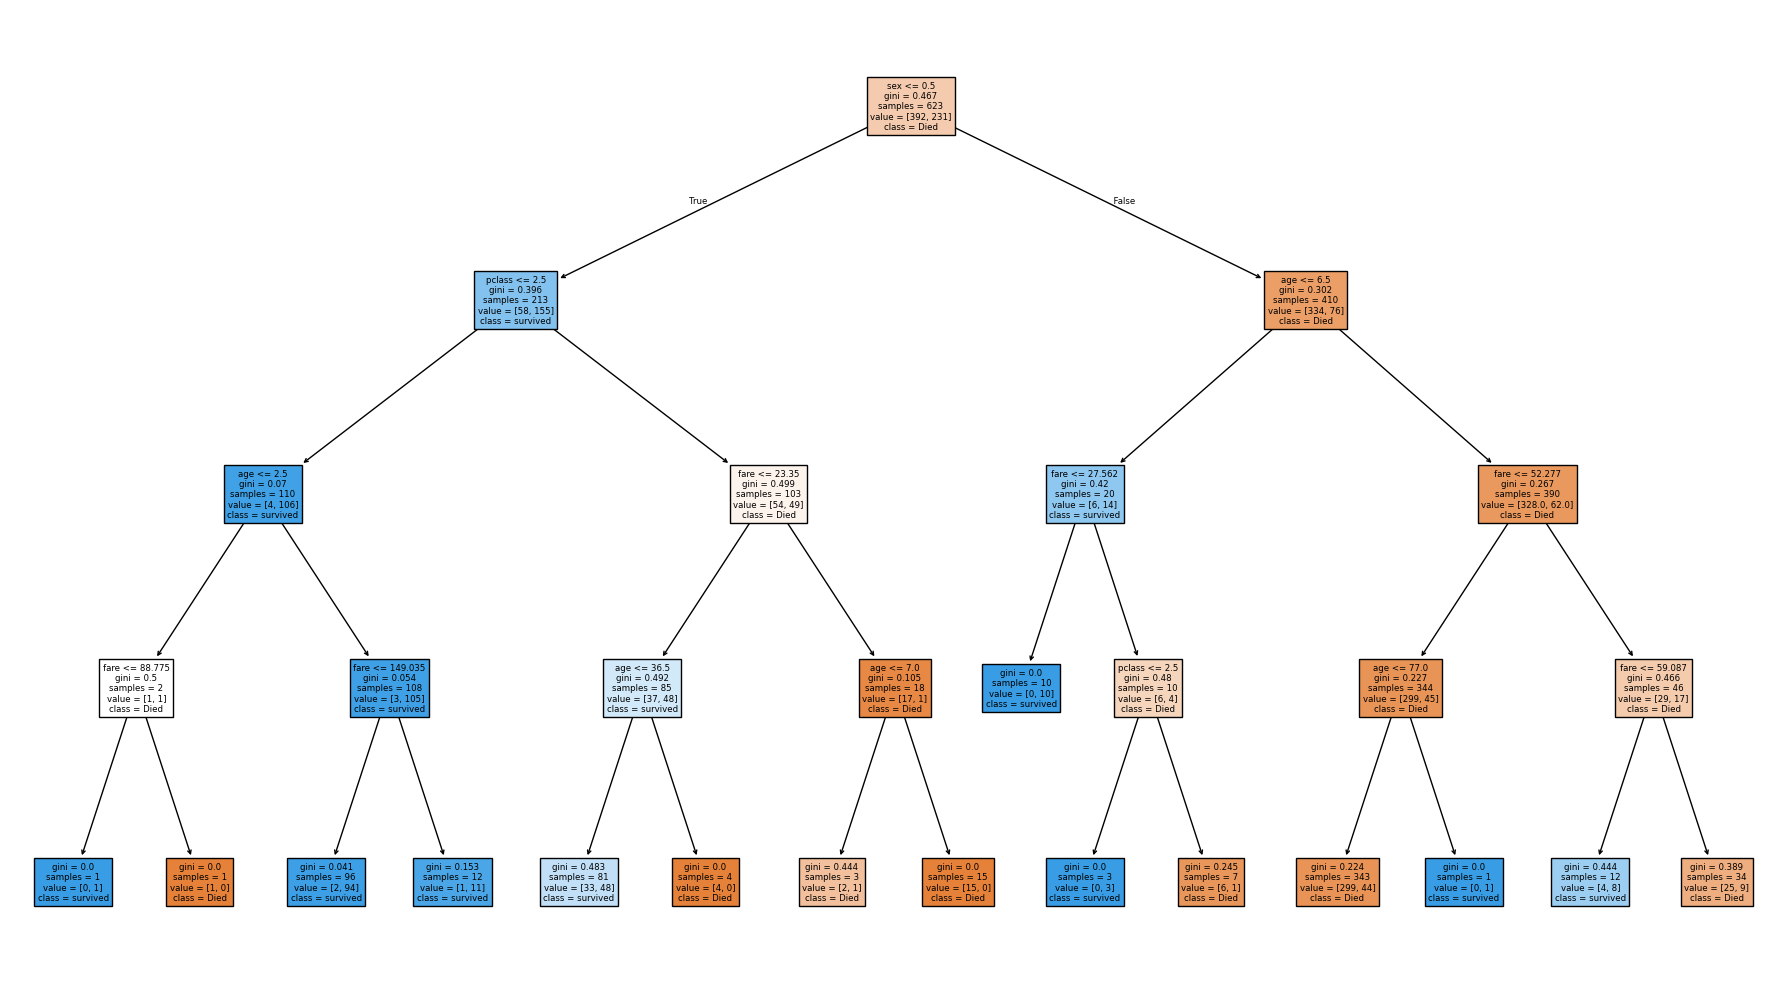

for depth = 5,accuracy = 0.7985074626865671
for depth = 6,accuracy = 0.7873134328358209
for depth = 7,accuracy = 0.7798507462686567
for depth = 8,accuracy = 0.7947761194029851
for depth = 9,accuracy = 0.7649253731343284
for depth = 10,accuracy = 0.7835820895522388


In [11]:
max_depth = [2,3,4,5,6,7,8,9,10]
for depth in max_depth:
    model = DecisionTreeClassifier(max_depth = depth)
    model.fit(X_train,y_train)

    acc = model.score(X_test,y_test)
    print(f"for depth = {depth},accuracy = {acc}")

    if depth == 4 :
        plt.figure(figsize=(18,10))
        plot_tree(
            model,
            feature_names = X.columns,
            class_names = ["Died","survived"],
            filled = True,
            
        )
        plt.tight_layout()
        plt.show()

for min sample splits = 10,accuracy = 0.8246268656716418


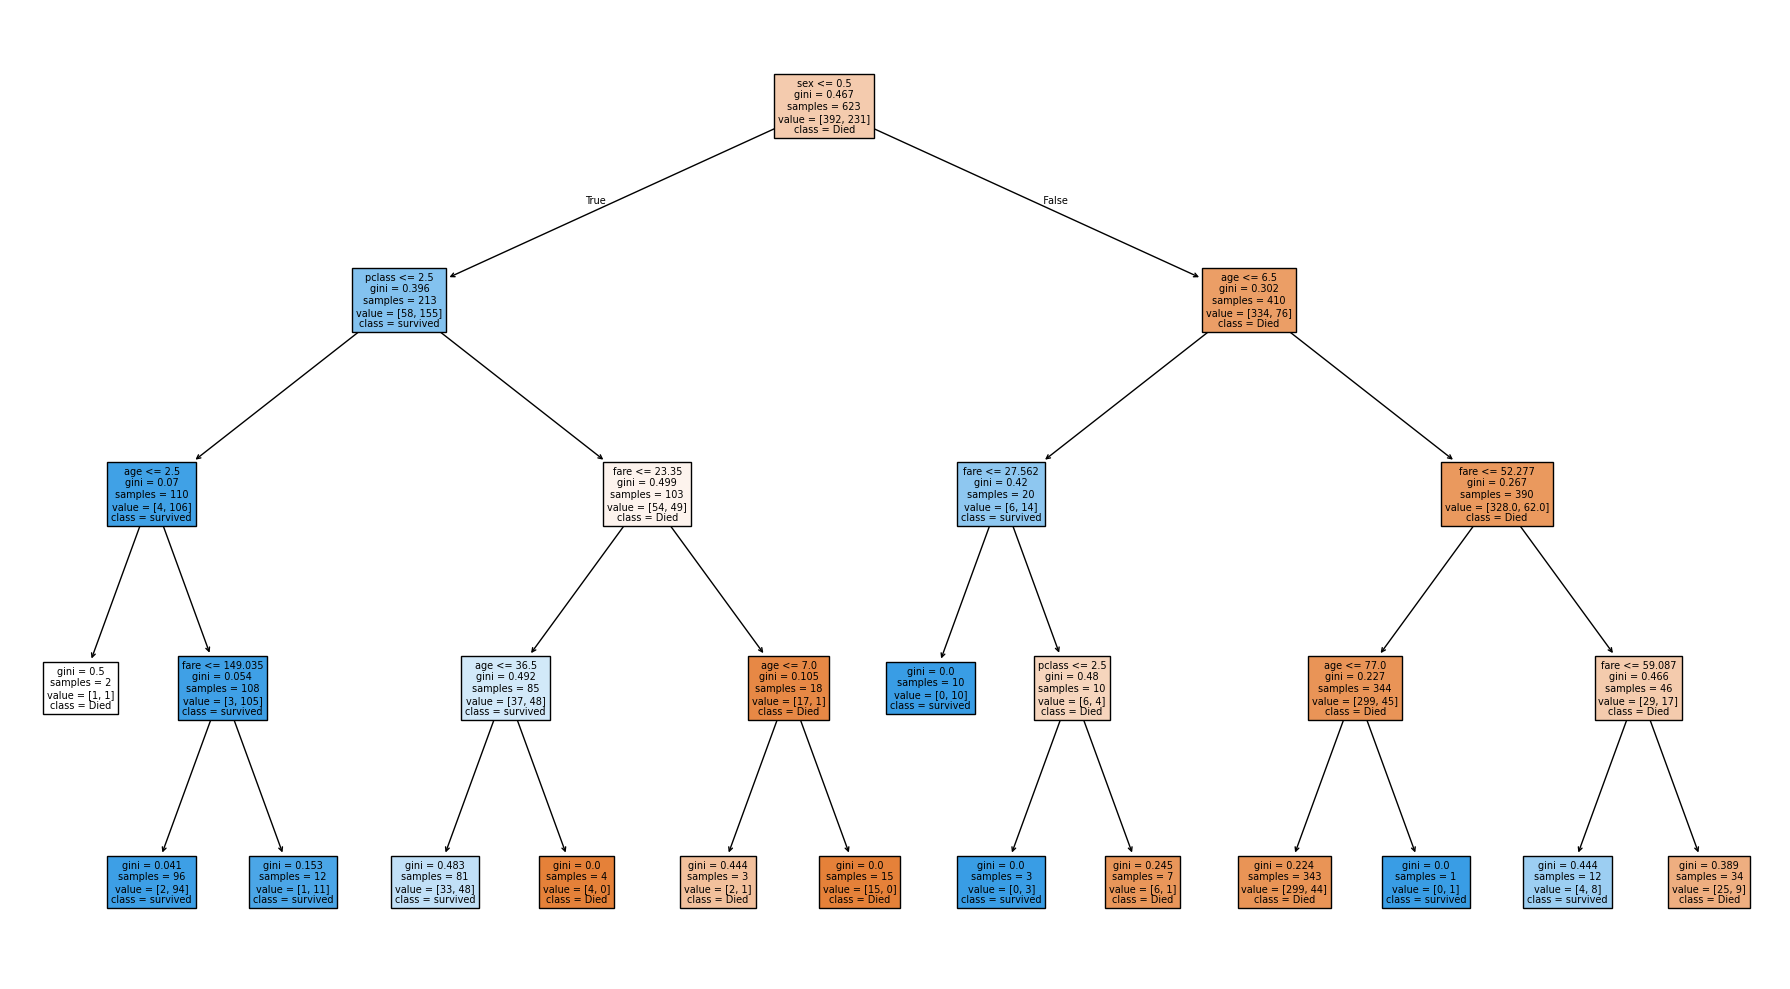

for min sample splits = 15,accuracy = 0.8171641791044776
for min sample splits = 20,accuracy = 0.8171641791044776
for min sample splits = 25,accuracy = 0.8208955223880597
for min sample splits = 30,accuracy = 0.8208955223880597


In [12]:
min_samples_splits = [10,15,20,25,30]
for split in min_samples_splits:
    model = DecisionTreeClassifier(max_depth = 4, min_samples_split = split)
    model.fit(X_train,y_train)

    acc = model.score(X_test,y_test)
    print(f"for min sample splits = {split},accuracy = {acc}")

    if split==10:
        plt.figure(figsize=(18,10))
        plot_tree(
            model,
            feature_names = X.columns,
            class_names = ["Died","survived"],
            filled = True,
            
        )
        plt.tight_layout()
        plt.show()

# Decision Tree post pruning

In [13]:
full_tree = DecisionTreeClassifier(random_state = 42)
full_tree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [14]:
path = full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.         0.         0.00013376 0.00013376 0.00022931 0.00032103
 0.00048409 0.00053505 0.00053505 0.00053505 0.00062746 0.00064205
 0.00077709 0.00085607 0.00093633 0.00096308 0.00096308 0.00096308
 0.00099875 0.00101659 0.00104193 0.0010478  0.00107009 0.00109238
 0.00115927 0.0012352  0.00123729 0.00129646 0.00132211 0.00133563
 0.00137583 0.00137583 0.00139708 0.00143228 0.00144145 0.00150482
 0.00151596 0.00152184 0.00171215 0.00183444 0.0019012  0.00195674
 0.00200642 0.00214018 0.00233474 0.0024077  0.00260835 0.00263292
 0.00278606 0.00280169 0.00284379 0.00288925 0.00299625 0.00302412
 0.00431144 0.00495299 0.00577849 0.00589431 0.0074248  0.01236198
 0.01787674 0.04065074 0.1323581 ]


In [18]:
#train our model for all alphas
trees = []
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state = 42,ccp_alpha = alpha)
    model.fit(X_train,y_train)
    acc = model.score(X_test,y_test)

    trees.append((model,alpha))

In [19]:
best_acc = 0
best_alpha = 0
for model,alpha in trees:
    curr_acc = model.score(X_test,y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha


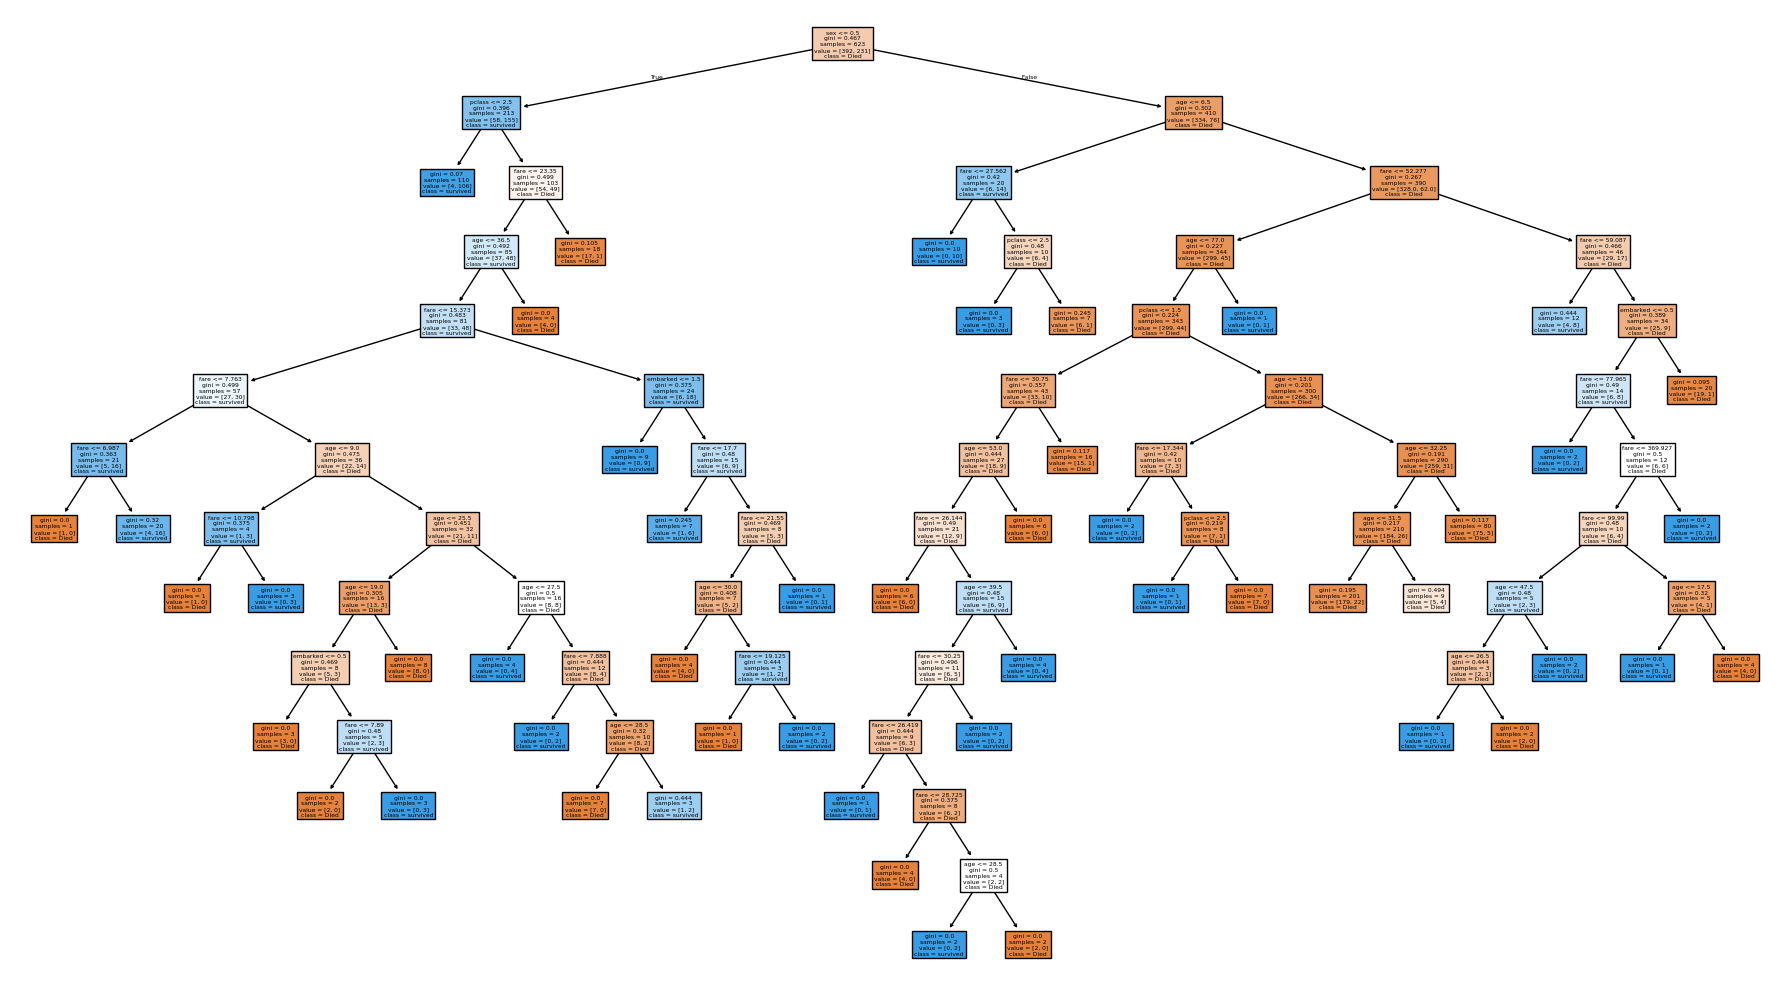

In [25]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha)
best_model.fit(X_train,y_train)
plt.figure(figsize=(18,10))
plot_tree(
    best_model,
    feature_names = X.columns,
    class_names = ["Died","survived"],
    filled = True,
            
)
plt.tight_layout()
plt.show()

In [ ]:
print(best_model.score(X_tes))